In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("deep_learning_dataset1.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
# at = tempreture
# v = vacume
# ap = presure
# rh = humadity

# pe = energy reduce / output

In [5]:
X = df.drop("PE",axis = 1)
y = df["PE"]

In [6]:
# split data and satnderdize 

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size = 0.2,random_state = 42)

# standerd our values
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
# converting the data into tensors
import torch 
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype = torch.float32)
X_test_tensor = torch.tensor(X_test_scaled,dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.values,dtype = torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values,dtype = torch.float32).view(-1,1)


In [8]:
# train_dataset = TensorDataset(input_features,output_features) 
from torch.utils.data import TensorDataset,DataLoader

train_dataset = TensorDataset(X_train_tensor,y_train_tensor) 
test_dataset = TensorDataset(X_test_tensor,y_test_tensor) 

In [9]:
# data load to the tensros form

train_loader = DataLoader(train_dataset,batch_size=32,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size=32)


## Deep learning Start

In [10]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model = nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),
    
            # 2nd layer
            nn.Linear(6,6),
            nn.ReLU(),
    
            # output layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)
        
        

In [11]:
import torch.optim as optim

model = ANN()

# loss,optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())



In [12]:
# training our ann model
training_loses = []
val_losses = []
best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    # xb = features of one batch
    # yb = labels of 1 batch
    
    for xb,yb in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(xb) #predicted output
        loss = criterion(outputs,yb) #compute loss 
        loss.backward()  #back.. prop.. compute grediants
        optimizer.step() #parameter update

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    training_loses.append(epoch_train_loss)

    # validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): #no grad compute
        for xb,yb in test_loader:
        
            outputs = model(xb)
            loss = criterion(outputs,yb)    
            running_val_loss += loss
        
    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} and val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss :
       best_val_loss = epoch_val_loss
       torch.save(model.state_dict(),"best_model.pt")
print(best_val_loss)

epoch 1/100 ==> train loss = 205693.2689453125 and val loss = 203729.5
epoch 2/100 ==> train loss = 197134.52740885416 and val loss = 186126.984375
epoch 3/100 ==> train loss = 166107.973046875 and val loss = 141584.65625
epoch 4/100 ==> train loss = 112635.06298828125 and val loss = 83698.53125
epoch 5/100 ==> train loss = 59889.36271158854 and val loss = 40727.0390625
epoch 6/100 ==> train loss = 30300.952522786458 and val loss = 23459.861328125
epoch 7/100 ==> train loss = 20384.352612304687 and val loss = 18072.740234375
epoch 8/100 ==> train loss = 16505.64373779297 and val loss = 14785.6669921875
epoch 9/100 ==> train loss = 13473.60995686849 and val loss = 11843.8759765625
epoch 10/100 ==> train loss = 10563.606508382161 and val loss = 9063.2470703125
epoch 11/100 ==> train loss = 7916.241855875651 and val loss = 6560.794921875
epoch 12/100 ==> train loss = 5557.171178181966 and val loss = 4438.859375
epoch 13/100 ==> train loss = 3656.113865152995 and val loss = 2823.1801757812

Text(0, 0.5, 'Losses')

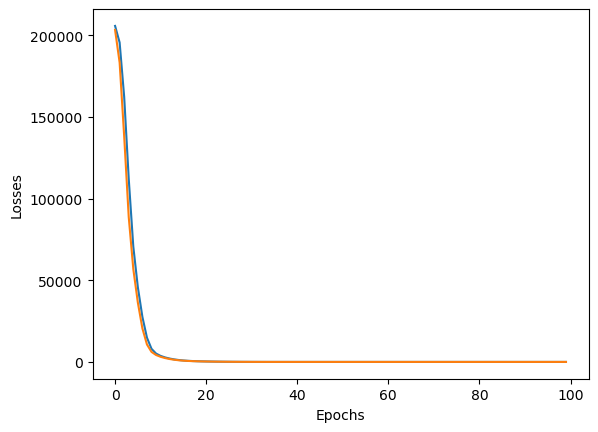

In [13]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Trainig_loss" : training_loses,
    "Validation_loss" : val_losses
})

plt.plot(loss_df["Trainig_loss"] ,label = "Trainig_loss")
plt.plot(loss_df["Validation_loss"] ,label = "Validation_loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

In [14]:
# loading the best model

model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [15]:
# Evealuate our model

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterion(train_preds,y_train_tensor)    
    test_mse_loss = criterion(test_preds,y_test_tensor)    

print("Training mse = ", train_mse_loss.item())
print("Testing mse = ", test_mse_loss.item())

Training mse =  20.655166625976562
Testing mse =  19.21626853942871


In [18]:
from sklearn.metrics import r2_score

print("r2_score is :",r2_score(y_test,test_preds))

r2_score is : 0.9328441067158162


In [21]:
pred_df = pd.DataFrame(test_preds.numpy(),columns = ["Predicted Values"])
actual_df = pd.DataFrame(y_test.values,columns = ["Actual Values"])

compare_df = pd.concat([pred_df,actual_df] , axis = 1)
compare_df

,Predicted Values,Actual Values
0,435.445648,433.27
1,437.221344,438.16
2,461.492065,458.42
3,476.646637,480.82
4,435.262756,441.41
...,...,...
1909,451.790680,456.70
1910,431.842865,438.04
1911,467.975433,467.80
1912,431.257904,437.14
